In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv('Algerian_forest_fires_Cleaned.csv')

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
### we not neeed day,month,year colums so drop it 
df.drop(['day','month','year'],axis=1,inplace=True )

In [5]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [6]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [7]:
## encoding to fix it
df['Classes']=np.where(df['Classes'].str.contains('not fire'),0,1)

In [8]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [9]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
242,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [10]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

# Independent Features (X) → Inputs
# Dependent Feature (y) → Output/Target 

In [11]:
x=df.drop('FWI',axis=1) ##removes the target column and keeps all input features.
y=df['FWI']

## or 

#X = df.iloc[:, :-1]
#y = df.iloc[:, -1]


#:      → all rows
#:-1    → all columns except last
#-1     → last column

In [12]:
x.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [13]:
y.head()  ## FWI column as ouput column

0    0.5
1    0.4
2    0.1
3    0.0
4    0.5
Name: FWI, dtype: float64

# Train test split

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.20,random_state=42)

In [15]:
df.shape

(243, 12)

In [16]:
x_train.shape ## split in 80:20 ratio

(48, 11)

In [17]:
x_test.shape

(195, 11)

# Feature Selection based on correlation

In [18]:
x_train.corr()  ## If some features are highly correlated, then remove

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.483406,-0.268265,-0.429508,0.777834,0.608813,0.442079,0.665654,0.562414,0.705930,0.343428
RH,-0.483406,1.000000,0.392061,0.262666,-0.572907,-0.215697,-0.015535,-0.575492,-0.145120,-0.349809,-0.607273
Ws,-0.268265,0.392061,1.000000,0.208180,-0.268652,-0.120535,0.055692,-0.261245,-0.058308,-0.253451,-0.329780
Rain,-0.429508,0.262666,0.208180,1.000000,-0.724600,-0.423049,-0.435088,-0.504198,-0.435119,-0.508784,-0.065594
FFMC,0.777834,-0.572907,-0.268652,-0.724600,1.000000,0.659728,0.560462,0.788537,0.640466,0.783000,0.288398
DMC,0.608813,-0.215697,-0.120535,-0.423049,0.659728,1.000000,0.897967,0.628587,0.986166,0.713893,0.234240
DC,0.442079,-0.015535,0.055692,-0.435088,0.560462,0.897967,1.000000,0.471661,0.955765,0.668523,-0.037878
ISI,0.665654,-0.575492,-0.261245,-0.504198,0.788537,0.628587,0.471661,1.000000,0.585653,0.770794,0.255546
BUI,0.562414,-0.145120,-0.058308,-0.435119,0.640466,0.986166,0.955765,0.585653,1.000000,0.713288,0.129625
Classes,0.705930,-0.349809,-0.253451,-0.508784,0.783000,0.713893,0.668523,0.770794,0.713288,1.000000,0.167248


### check for multicollinearity(independent feature correated )

<Axes: >

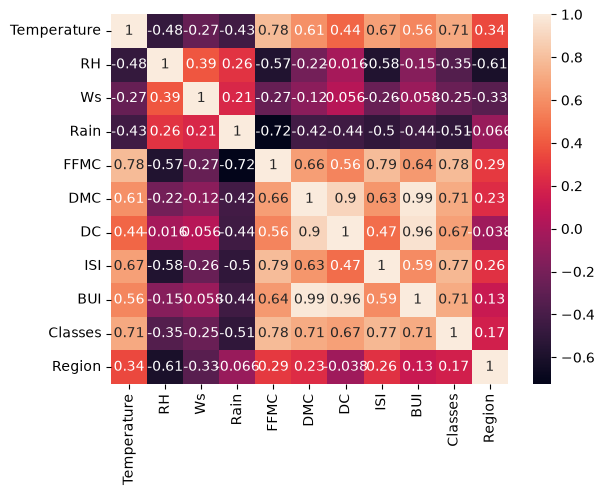

In [19]:
plt.Figure(figsize=(18,10))
cor=x_train.corr()
sns.heatmap(cor,annot=True) ## annot add number inside block

### checking  multicollinearity with threshold(0.95) value

In [20]:
## This code is used to find highly correlated features
def correlation(dataset,threshold):
     col_corr=set() ## create a empty set(Store columns that should be removed.)
     col_matrix=dataset.corr()
     for i in range(len(col_matrix.columns)):
          for j in range(i):
               if abs(col_matrix.iloc[i,j]>threshold):
                    col_name=col_matrix.columns[i]
                    col_corr.add(col_name)
     return col_corr              


In [21]:
corr_feature=correlation(x_train,0.85)

In [22]:
## drop feature when correlation is more than 0.85
x_train.drop(corr_feature,axis=1,inplace=True)
x_test.drop(corr_feature,axis=1,inplace=True)
x_test.shape,x_train.shape ## 2 colums are removed

((195, 9), (48, 9))

In [23]:
x_train.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
63,35,63,14,0.3,76.6,5.7,1.7,0,0
54,31,65,18,0.0,84.3,12.5,4.8,1,0
107,30,65,14,0.0,78.1,3.2,1.9,0,0
50,33,70,17,0.0,85.4,18.5,5.2,1,0
201,36,81,15,0.0,83.7,34.4,3.8,1,1


# Feature scaling and Standardization

In [24]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [25]:
x_train_scaled

array([[ 8.64110122e-01, -8.84378775e-03, -5.81040353e-01,
        -3.49388198e-01,  2.91901261e-04, -7.86341775e-01,
        -6.95792379e-01, -1.08711461e+00, -1.00000000e+00],
       [-1.99410028e-01,  1.32656816e-01,  9.26523806e-01,
        -5.42154101e-01,  5.39725432e-01, -2.38270122e-01,
         2.45424948e-01,  9.19866211e-01, -1.00000000e+00],
       [-4.65290066e-01,  1.32656816e-01, -5.81040353e-01,
        -5.42154101e-01,  1.05376355e-01, -9.87838707e-01,
        -6.35068681e-01, -1.08711461e+00, -1.00000000e+00],
       [ 3.32350047e-01,  4.86408326e-01,  5.49632766e-01,
        -5.42154101e-01,  6.16787365e-01,  2.45322514e-01,
         3.66872345e-01,  9.19866211e-01, -1.00000000e+00],
       [ 1.12999016e+00,  1.26466165e+00, -2.04149313e-01,
        -5.42154101e-01,  4.97691650e-01,  1.52684300e+00,
        -5.81935444e-02,  9.19866211e-01,  1.00000000e+00],
       [ 3.32350047e-01, -8.84378775e-03,  5.49632766e-01,
         1.64654208e-01, -2.65922049e-01,  4.387595

## Boxplot to undersatnd the effect of standardization data (before and after)

Text(0.5, 1.0, 'X_train data After scaling')

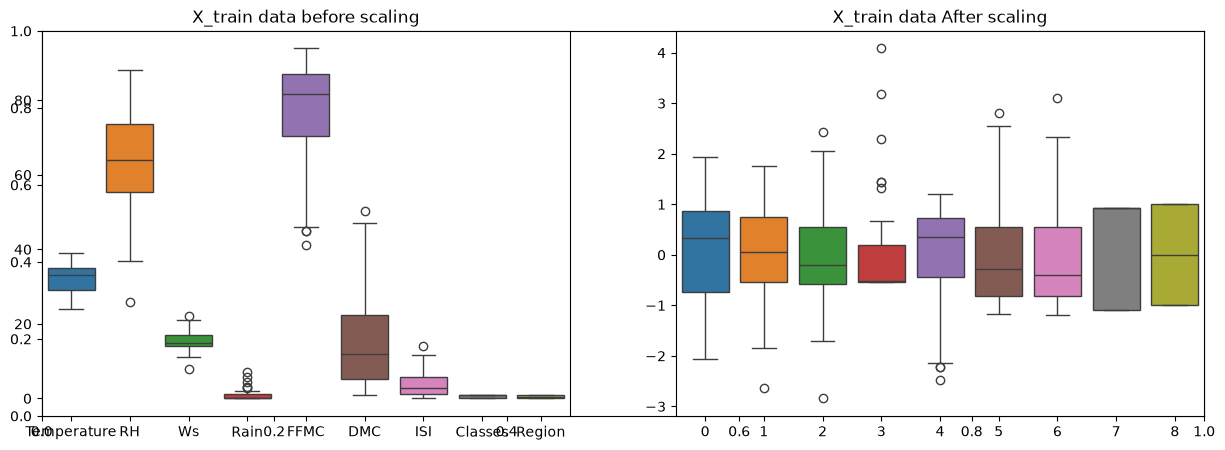

In [26]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=x_train)## prev data
plt.title('X_train data before scaling')

plt.subplot(1,2,2)
sns.boxplot(data=x_train_scaled)## prev data
plt.title('X_train data After scaling')

# Model Training

# 1) Linear Regession Model

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg=LinearRegression()
linreg.fit(x_train_scaled,y_train) ## train model with scaller x_train data and output y_train
y_pred_1=linreg.predict(x_test_scaled) ## predict value based on train model on x_test data
Mae=mean_absolute_error(y_test,y_pred_1)
rsquared=r2_score(y_test,y_pred_1)
print("MAE:- ",Mae)
print("R2:-",rsquared)


MAE:-  0.77453820701087
R2:- 0.9630546865725841


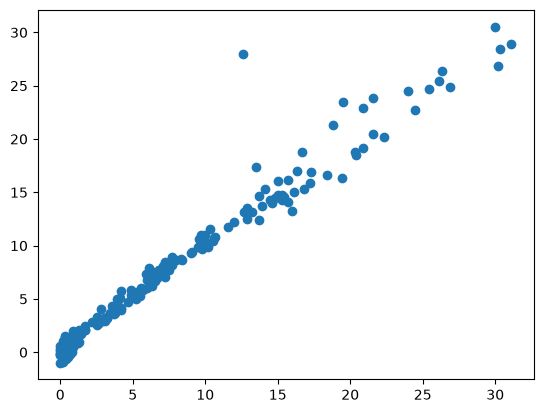

In [28]:
plt.scatter(y_test,y_pred_1) ## its good model its follow linearity

# 2) Lasso model

In [29]:
#### this model help to remove feature which is not that much important

In [30]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error ,r2_score
lasso=Lasso()
lasso.fit(x_train_scaled,y_train)
y_pred_2=lasso.predict(x_test_scaled)
Mae=mean_absolute_error(y_test,y_pred_2)
rsquared=r2_score(y_test,y_pred_2)
print("MAE:- ",Mae)
print("R2:-",rsquared)


MAE:-  1.444709654510238
R2:- 0.9252916076971631


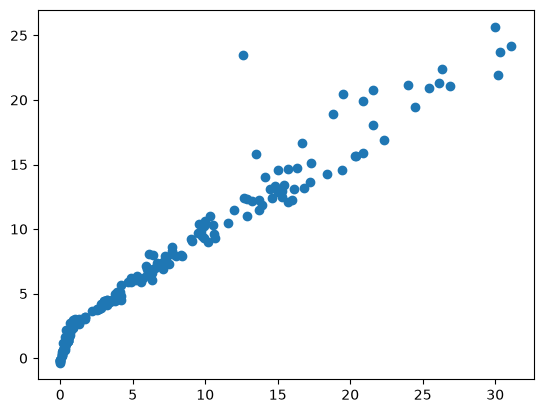

In [31]:
plt.scatter(y_test,y_pred_2)

### It may be overfitting so used 3rd model

# Cross validation Lasso


- LassoCV = Lasso Regression + Cross Validation.
- Automatically finds the best alpha value.
- Reduces manual hyperparameter tuning.
- `cv=5` means 5-Fold Cross Validation.

Best alpha:

In [32]:
from sklearn.linear_model import LassoCV
lasscocv=LassoCV(cv=5)
lasscocv.fit(x_train_scaled,y_train)

,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"alphas alphas: array-like or int, default=100Values of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as an argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, `X` will be copied; otherwise, it may be overwritten.",True
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"positive positive: bool, default=FalseIf positive, restrict regression coefficients to be positive.",False


In [33]:
# lasscocv.predict(x_test_scaled) ## we can also predict by this 
lasscocv.alpha_  ## its give in which alpha model perform well 

np.float64(0.007644554776887191)

In [34]:
lasscocv.alphas_ ## on which alpha(total=100) value tested

array([5.78282534, 5.39308227, 5.02960658, 4.69062793, 4.3744953 ,
       4.07966896, 3.80471293, 3.54828801, 3.30914527, 3.08611996,
       2.8781258 , 2.68414975, 2.50324704, 2.33453657, 2.17719662,
       2.03046085, 1.89361459, 1.7659913 , 1.6469694 , 1.53596917,
       1.43244999, 1.33590766, 1.24587195, 1.16190435, 1.08359589,
       1.01056515, 0.94245644, 0.87893803, 0.81970055, 0.76445548,
       0.71293374, 0.66488439, 0.62007341, 0.57828253, 0.53930823,
       0.50296066, 0.46906279, 0.43744953, 0.4079669 , 0.38047129,
       0.3548288 , 0.33091453, 0.308612  , 0.28781258, 0.26841498,
       0.2503247 , 0.23345366, 0.21771966, 0.20304609, 0.18936146,
       0.17659913, 0.16469694, 0.15359692, 0.143245  , 0.13359077,
       0.1245872 , 0.11619044, 0.10835959, 0.10105652, 0.09424564,
       0.0878938 , 0.08197006, 0.07644555, 0.07129337, 0.06648844,
       0.06200734, 0.05782825, 0.05393082, 0.05029607, 0.04690628,
       0.04374495, 0.04079669, 0.03804713, 0.03548288, 0.03309

In [35]:
lasscocv.mse_path_ ## gives all mse value which calculate during try on

array([[22.70974851, 68.63927562, 45.8178518 , 28.84926795, 38.57349551],
       [19.91081933, 66.56028962, 43.41211597, 26.2856395 , 33.85154264],
       [17.50220794, 61.65362921, 41.62552732, 24.04290825, 29.78306452],
       [15.40721513, 57.26508373, 40.01194845, 22.08015439, 26.23093045],
       [13.58504621, 53.33532202, 38.55286793, 20.36172882, 22.66244717],
       [12.00010429, 49.81219131, 37.23191427, 18.85657062, 19.30967559],
       [10.62152725, 46.64981927, 36.03459556, 17.53761316, 16.42998707],
       [ 9.42244094, 43.80783054, 33.2204625 , 16.38126732, 13.95933499],
       [ 8.37954086, 41.25066294, 28.59667706, 15.36697172, 11.84198877],
       [ 7.47235502, 38.94697058, 24.60428261, 13.41307721, 10.03012794],
       [ 6.68327357, 36.86910272, 21.15928987, 11.41643269,  8.48180493],
       [ 5.99691719, 34.9926486 , 18.18920338,  9.7033683 ,  7.16083744],
       [ 5.39990945, 33.22993819, 15.62909053,  8.23492902,  6.03588112],
       [ 4.88061598, 30.56818833, 13.4

MAE:-  0.7756324741377735
R2:- 0.9631580674236087


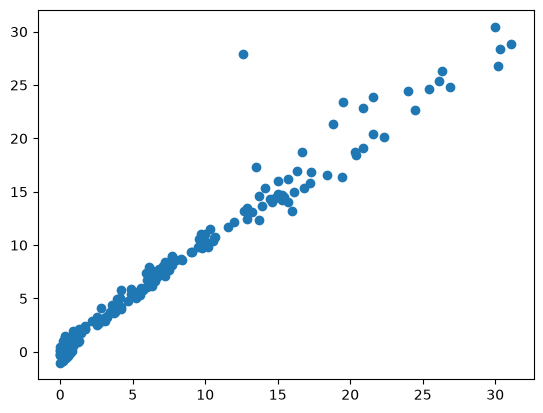

In [36]:
y_pred_lasso=lasscocv.predict(x_test_scaled)
plt.scatter(y_test,y_pred_lasso)
Mae=mean_absolute_error(y_test,y_pred_lasso)
rsquared=r2_score(y_test,y_pred_lasso)
print("MAE:- ",Mae)
print("R2:-",rsquared)

# 3) Ridge model

In [37]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error ,r2_score
ridge=Ridge()
ridge.fit(x_train_scaled,y_train)
y_pred_3=ridge.predict(x_test_scaled)
Mae=mean_absolute_error(y_test,y_pred_3)
rsquared=r2_score(y_test,y_pred_3)
print("MAE:- ",Mae)
print("R2:-",rsquared)


MAE:-  0.8349057237408689
R2:- 0.96350668653875


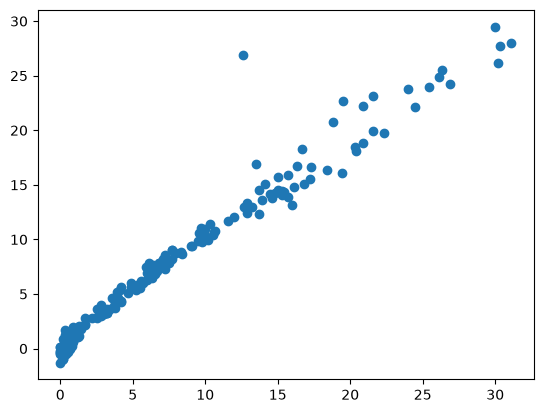

In [38]:
plt.scatter(y_test,y_pred_3)

# Cross validation Ridge

In [39]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5) ## if we not provide cv the by dffault its a Leave-One-Out CV (LOOCV) [Train = 99 rows Test  = 1 row]
ridgecv.fit(x_train_scaled,y_train)

,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.",5
,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.For an example on how regularization strength affects the model coefficients,see :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`.","(0.1, ...)"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error <mean_squared_error>` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination <r2_score>` (:math:`R^2`) otherwise.",None
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : same as 'eigen' 'svd' : use singular value decomposition of X when X is dense, fallback to 'eigen' when X is sparse 'eigen' : use eigendecomposition of X X' when n_samples <= n_features or X' X when n_features < n_samplesThe 'auto' mode is the default and is intended to pick the cheaperoption depending on the shape and sparsity of the training data.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation values corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False
,"alpha_per_target alpha_per_target: bool, default=FalseFlag indicating whether to optimize the alpha value (picked from the`alphas` parameter list) for each target separately (for multi-outputsettings: multiple prediction targets). When set to `True`, afterfitting, the `alpha_` attribute will contain a value for each target.When set to `False`, a single alpha is used for all targets.This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionadded:: 0.24",False
Name,Type,Value
"alpha_ alpha_: float or ndarray of shape (n_targets,)Estimated regularization parameter, or, if ``alpha_per_target=True``,the estimated regularization parameter for each target.",float64,0.1
"best_score_ best_score_: float or ndarray of shape (n_targets,)Score of base estimator with best alpha, or, if``alpha_per_target=True``, a score for each target... versionadded:: 0.23",float64,0.972
"coef_ coef_: ndarray of shape (n_features) or (n_targets, n_features)Weight vector(s).","ndarray[float64](9,)","[-0.13, 0.12,-0.1 ,..., 4.53, 0.23,-0.42]"


In [40]:
y_pred_ridge=ridgecv.predict(x_test_scaled)

MAE:-  0.778055180558005
R2:- 0.9632338286049047


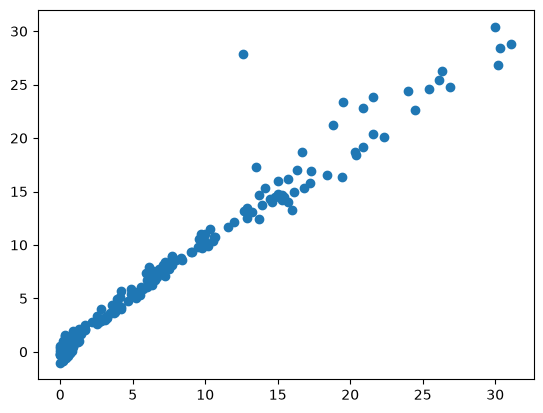

In [41]:

plt.scatter(y_test,y_pred_ridge)
Mae=mean_absolute_error(y_test,y_pred_ridge)
rsquared=r2_score(y_test,y_pred_ridge)
print("MAE:- ",Mae)
print("R2:-",rsquared)

In [42]:
ridgecv.alpha_ # gives the best alpha value found by Cross Validation.

np.float64(0.1)

In [43]:
ridgecv.alphas ## its only select these 3 number and check (here 0.1 is work well)

(0.1, 1.0, 10.0)

# Elasticnet Regression Model(lasso+ridge)

### inside `Elasticnet parameter` we have
####  ElasticNet(alpha=1.0, l1_ratio=0.5)
```

- `l1_ratio` controls the mix of L1 (Lasso) and L2 (Ridge) regularization.

In [44]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error ,r2_score
elasticnet=ElasticNet()
elasticnet.fit(x_train_scaled,y_train)
y_pred_4=elasticnet.predict(x_test_scaled)
Mae=mean_absolute_error(y_test,y_pred_4)
rsquared=r2_score(y_test,y_pred_4)
print("MAE:- ",Mae)
print("R2:-",rsquared)

MAE:-  2.1828357146886646
R2:- 0.8389672737960475


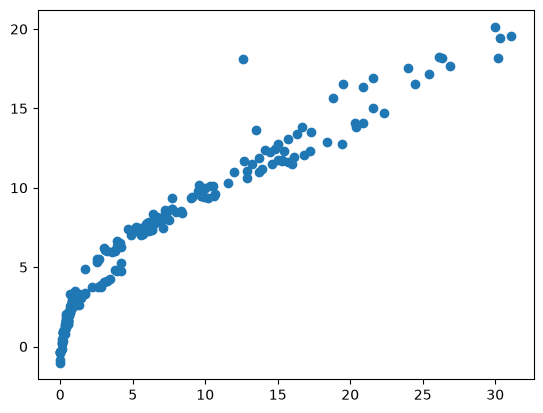

In [45]:
plt.scatter(y_test,y_pred_4)

# Cross validation Elasticnet

In [46]:
from sklearn.linear_model import ElasticNetCV
elasticnetcv=ElasticNetCV(cv=5)
elasticnetcv.fit(x_train_scaled,y_train)
y_pred_elastic=elasticnetcv.predict(x_test_scaled)

MAE:-  0.7912100418601774
R2:- 0.9635624134674456


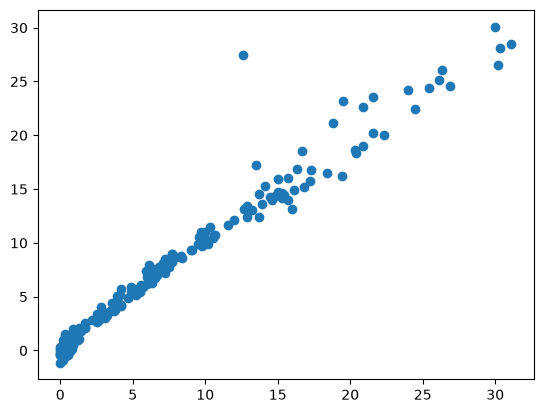

In [47]:

plt.scatter(y_test,y_pred_elastic)
Mae=mean_absolute_error(y_test,y_pred_elastic)
rsquared=r2_score(y_test,y_pred_elastic)
print("MAE:- ",Mae)
print("R2:-",rsquared)

In [48]:
elasticnetcv.alphas

100

In [49]:
elasticnetcv.alpha_

np.float64(0.014258674740714204)

# Pickling

In [51]:
scaler

StandardScaler()

In [52]:
ridge

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [53]:
import pickle
pickle.dump(scaler, open("scaler.pkl","wb"))
pickle.dump(ridge, open("ridge.pkl","wb"))